In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir("/content/drive/MyDrive/Jersey_Detection/image_segmentation/sam3")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from huggingface_hub import login
login()

In [3]:
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA is available: True


In [ ]:
!git clone https://github.com/facebookresearch/sam3.git

fatal: destination path 'sam3' already exists and is not an empty directory.


In [4]:
!pip install -e .

Obtaining file:///content/drive/MyDrive/Jersey_Detection/image_segmentation/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 102.7 MB/s eta 0:00:00
  Building editable for sam3 (pyproject.toml) ... done
  Created wheel for sam3: filename=sam3-0.1.0-0.editable-py3-none-any.whl size=15935 sha256=297ef416033ff71cb3f8f21ef65dbfd67e5fd8bcf03d07b3296de0bedb31a2e6
  Stored in directory: /tmp/pip-ephem-wheel-cache-9tc1vazp/wheels/79/02/a7/d5dbd045fe3559bf701d184df822ead2a4258eae7599448d4b
  Created whee

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

import sam3
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

In [11]:
!pip install segment

In [2]:
import torch

# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

In [3]:
os.chdir("/content/drive/MyDrive/Jersey_Detection/image_segmentation/sam3/sam3")

In [5]:
bpe_path = f"assets/bpe_simple_vocab_16e6.txt.gz"
model = build_sam3_image_model(bpe_path=bpe_path)

config.json: 0.00B [00:00, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

In [46]:
image_path = f"/content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/maroon_B63W9232-24-5-36-18-19.jpg"
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.7)
inference_state = processor.set_image(image)

found 4 object(s)


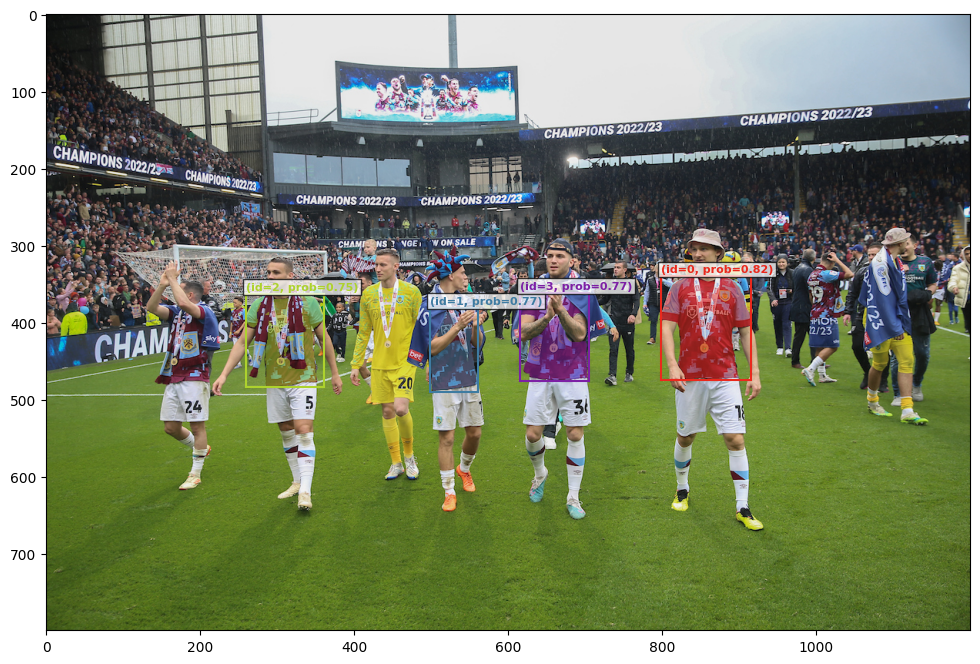

In [64]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="Jersey Numbers of Athletes with Maroon Jersey Tops")
img0 = Image.open(image_path)
plot_results(img0, inference_state)

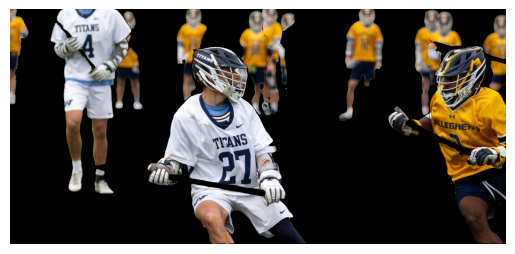

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files
masks, boxes, scores = inference_state["masks"], inference_state["boxes"], inference_state["scores"]
image_array = np.array(img0)
full_mask = np.zeros((image_array.shape[0], image_array.shape[1], image_array.shape[2]))
for mask in masks:
  bool_mask = mask.cpu().numpy().astype(np.uint8)
  mask_squeeze = np.squeeze(bool_mask, axis = 0)
  temp_mask = np.zeros((image_array.shape[0], image_array.shape[1], image_array.shape[2]))
  for i in range(3):
    temp_mask[:,:, i] = mask_squeeze
  full_mask += (image_array * temp_mask)
result_img = Image.fromarray(full_mask.astype(np.uint8))
plt.imshow(result_img)
plt.axis('off')
plt.show()

In [54]:
import segment
import importlib
from pathlib import Path
import gc
#image_folder = Path("/content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/jersey numbers")
image_folder = Path("/content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors")
image_files = [str(f) for f in image_folder.iterdir() if f.is_file()]
processor = Sam3Processor(model, confidence_threshold=0.7)

194


In [62]:
def import_image(image_path, img_color):
  image = Image.open(image_path)
  width, height = image.size
  with torch.inference_mode():
    inference_state = processor.set_image(image)
    processor.reset_all_prompts(inference_state)
    #inference_state = processor.set_text_prompt(state=inference_state, prompt="Playing Athletes")
    inference_state = processor.set_text_prompt(state=inference_state, prompt=f"Whole Athletes with {img_color} Jersey Tops")
    print("Image Segmented")
    img = Image.open(img_path)
    masks = inference_state["masks"].cpu()
    image_array = np.array(img)
    full_mask = np.zeros((image_array.shape[0], image_array.shape[1], image_array.shape[2]))
    masks = np.squeeze(masks, axis = 1)
    #areas = masks.sum(dim=(1,2))
    #sorted_indicies = torch.argsort(areas, descending=True)
    #sorted_masks = masks[sorted_indicies]
    overall_mask = np.zeros((image_array.shape[0], image_array.shape[1], image_array.shape[2]))
    for mask in masks:
      bool_mask = mask.cpu().numpy().astype(np.uint8)
      temp_mask = np.zeros((image_array.shape[0], image_array.shape[1], image_array.shape[2]))
      for i in range(3):
        temp_mask[:,:, i] = bool_mask
      overall_mask = np.maximum(overall_mask, temp_mask)
      del bool_mask, temp_mask
    full_mask = (image_array * overall_mask)
    del overall_mask
    result_img = Image.fromarray(full_mask.astype(np.uint8))
    updated_path = img_path.split("/")[-1]
    #result_img.save(f"/content/drive/MyDrive/Jersey_Detection/image_segmentation/outputs/sam3Images/{updated_path}")
    result_img.save(f"/content/drive/MyDrive/Jersey_Detection/image_segmentation/outputs/sam3ImagesColor/{updated_path}")
    del result_img, img, inference_state, masks, full_mask
    print("Background Removed & Image Saved")

In [63]:
cur_image = 1
for img_path in image_files:
  val = img_path.split('/')[7].split('_')[0]
  print(f"Cur_Image: {img_path}")
  print(f"Image: {cur_image}/{len(image_files)}")
  print(f"Val: {val}")
  import_image(img_path, val)
  cur_image += 1

Cur_Image: /content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/maroon_1113-10.jpg
Image: 1/194
Val: maroon
Image Segmented
Background Removed & Image Saved
Cur_Image: /content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/maroon_1115-10.jpg
Image: 2/194
Val: maroon
Image Segmented
Background Removed & Image Saved
Cur_Image: /content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/maroon_1119-19.jpg
Image: 3/194
Val: maroon
Image Segmented
Background Removed & Image Saved
Cur_Image: /content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/white_3621-54-33-21-7-0-35.jpg
Image: 4/194
Val: white
Image Segmented
Background Removed & Image Saved
Cur_Image: /content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/white_3350-28-88.jpg
Image: 5/194
Val: white
Image Segmented
Background Removed & Image Saved
Cur_Image: /c